In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/df_new.xlsx')

In [3]:
df = df_new.copy()
df.head(2)

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,Property_Description,Description,Property_Code,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,Incident?
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,0,0,0,N
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,0,0,0,N


In [4]:
df.rename(columns = {'Incident?':'INCIDENT'}, inplace = True)


In [5]:
df['INCIDENT'].value_counts(normalize = True)

INCIDENT
N    0.969203
Y    0.030797
Name: proportion, dtype: float64

In [6]:
df = df.drop(columns=['Addressbase UPRN','Unnamed: 0','Easting', 'Northing', 'CREATION_DATE',
       'FRSIncidentIdentifier', 'Year', 'Fiscal_Year', 'TimeOfCall',
       'ResponsiblePartyStationId', 'IncidentCategory', 'Property_Type',
       'Property_Description', 'Description', 'Property_Code',
       'VictimsInvolved', 'VictimType', 'WasRescued', 'Victim_Category',
       'EvacuationAssistanceInvolved', 'EquipmentUsed','ABP_Classification_Desc',
        'Household Acorn Category Description','Household Acorn Type Description_x',
        'Household Acorn Group Description', 'Household Acorn Type Description_y',
        '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag','Dependent Locality',
                      'Town','Station_Ground_Code',
                      '(H) Presence of Elderly Parent','AgeBracket_EldParent',
                      'Output Area'
                      ])

In [7]:
#print(df.isnull().sum())

In [8]:
df['INCIDENT'] = df['INCIDENT'].replace({'Y': '1', 'N': '0', '': pd.NA}).astype(pd.Int8Dtype())
#df.sample(3)

In [9]:
df.INCIDENT.value_counts()

INCIDENT
0    79779
1     2535
Name: count, dtype: Int64

SPLIT THE DATA:
Next, you define the target and features. This means separating the dataset into the input variables (X) and the target variable (y), which in your case is the Incident column.

In [10]:
cols = []
for c in df.columns:
    cols.append(c)
#cols

In [11]:
# target data
y = df[cols[-1]]
y.value_counts()

INCIDENT
0    79779
1     2535
Name: count, dtype: Int64

In [12]:
X_cols = cols[0:len(cols)-1]
X = df[df.columns.intersection(X_cols)]
X.shape

(82314, 15)

After defining the X, y features:
...perform a train/test split. The reason we do this relatively early is so that part of the data remains completely unseen during training. This allows us to properly evaluate whether the model generalises well.

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,stratify = y)

In [14]:
X.shape, X_test.shape, X_train.shape

((82314, 15), (16463, 15), (65851, 15))

In [15]:
y.shape, y_test.shape, y_train.shape

((82314,), (16463,), (65851,))

### Training set datatype == Int

In [16]:
X_train_int = X_train.dtypes[X_train.dtypes == 'int64']
X_train_int = X_train.select_dtypes('int64')
print(f'The are {X_train_int.shape[1]} float64 formats present >>>') 

X_train_int_features = X_train_int.columns
#X_train_int_features

The are 11 float64 formats present >>>


### Training set. datatype == Object/str

In [17]:
X_train_obj = X_train.select_dtypes('str')
X_train_obj_features = X_train_obj.columns
#X_train_obj_features

# PIPELINE
### Logistic Regression

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
 
# 1. Define which columns get which treatment

num_cols = X_train_int_features
#num_cols = ['(H) Age - Fine', '(H) Number of Adults in Household', '(H) Length of Residency', '(H) Affluence v2']
cat_cols = X_train_obj_features
#cat_cols = ['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name', 'LSOA11CD']

 
# 2. Create the transformers

preprocessor = ColumnTransformer(

    transformers=[

        ('num', StandardScaler(), num_cols),

        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)

    ], remainder='drop') # This automatically drops LSOA11CD and anything not listed above

# 3. Bundle it all with your model

pipeline_LogReg = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(class_weight='balanced', max_iter=500)) ]
                   )  
# Note: class_weight='balanced' forces the model to pay attention to the 3% of fires.


# 4. Fit the pipeline on training data

#pipeline_LogReg.fit(X_train, y_train)
 # we can get performance of the model on the TRAIN data set from 

# 5. Evaluate on TEST data (which you haven't done yet!)

#y_test_pred = pipeline.predict(X_test)



pipeline_LogReg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### fit: pipeline_logreg on TRAINING DATA: X_train

In [19]:
# 4. Fit the pipeline on training data
# we can get performance of the model on the TRAIN data set from 
pipeline_LogReg.fit(X_train, y_train)
y_TRAIN_pred_logreg = pipeline_LogReg.predict(X_train)
y_TRAIN_pred_logreg

array([0., 1., 0., ..., 1., 0., 0.])

In [20]:
# import the metrics class for TRAINING SET
from sklearn import metrics
# Run confusion matrix on TRAINING SET for LOGREG
cnf_matrix = metrics.confusion_matrix(y_train, y_TRAIN_pred_logreg)
cnf_matrix

array([[44007, 19816],
       [  706,  1322]])

In [21]:
## TRAINING SET: LogReg Classification

from sklearn.metrics import classification_report
target_names = ['0', '1']
print("LOGISTIC REGRESSION TRAINING SET")
print(classification_report(y_train, y_TRAIN_pred_logreg, target_names=target_names))

LOGISTIC REGRESSION TRAINING SET
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     63823
           1       0.06      0.65      0.11      2028

    accuracy                           0.69     65851
   macro avg       0.52      0.67      0.46     65851
weighted avg       0.96      0.69      0.79     65851



### Logistic Regression Pipeline for the TEST SET

In [22]:
pipeline_LogReg.fit(X_test, y_test)
y_TEST_pred_logreg = pipeline_LogReg.predict(X_test)
y_TEST_pred_logreg

array([1., 0., 0., ..., 1., 1., 0.])

In [23]:
# Run confusion matrix on TEST SET for LOGREG
cnf_matrix = metrics.confusion_matrix(y_test, y_TEST_pred_logreg)
cnf_matrix

array([[11448,  4508],
       [  131,   376]])

In [24]:
## TEST SET: LogReg Classification

from sklearn.metrics import classification_report
target_names = ['0', '1']
print("LOGISTIC REGRESSION TEST SET")
print(classification_report(y_test, y_TEST_pred_logreg, target_names=target_names))

LOGISTIC REGRESSION TEST SET
              precision    recall  f1-score   support

           0       0.99      0.72      0.83     15956
           1       0.08      0.74      0.14       507

    accuracy                           0.72     16463
   macro avg       0.53      0.73      0.49     16463
weighted avg       0.96      0.72      0.81     16463



#  pipeline version 2: pipeline_Random_Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

pipeline_Random_Forest = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', RandomForestClassifier(class_weight='balanced')) ])
pipeline_Random_Forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### fit the pipeline_Random_Forest onto TRAINING data: X_train, t_train

In [26]:
## TRAINING DATA

pipeline_Random_Forest.fit(X_train, y_train)

y_pred_rf_TRAIN = pipeline_Random_Forest.predict(X_train)

pipeline_Random_Forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [27]:
y_pred_rf_TRAIN

array([0., 0., 0., ..., 0., 0., 0.])

In [28]:
# Run confusion matrix on TRAIN SET for RANDOM FOREST
cnf_matrix = metrics.confusion_matrix(y_train, y_pred_rf_TRAIN)
cnf_matrix

array([[63315,   508],
       [   14,  2014]])

In [29]:
# Classification metrics for TRAINING DATA
target_names = ['0', '1']
print("classification_report on TRAIN SET for RANDOM FOREST")
print(classification_report(y_train, y_pred_rf_TRAIN, target_names=target_names))

classification_report on TRAIN SET for RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     63823
           1       0.80      0.99      0.89      2028

    accuracy                           0.99     65851
   macro avg       0.90      0.99      0.94     65851
weighted avg       0.99      0.99      0.99     65851



In [30]:
## Scenarios
# 1 data may be tooo good, not likley
# 2 data leakage? not likley sin logreg is poor
# 3. Overfitting. Too good with trainset
# Lets try on TEST set only

In [31]:
## Fit pipeline_Random_Forest on TEST DATA:
pipeline_Random_Forest.fit(X_test, y_test)
pipeline_Random_Forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
# Classification metrics for TEST DATA

y_pred_rf_TEST = pipeline_Random_Forest.predict(X_test)
target_names = ['0', '1']
print("classification_report on TEST SET for RANDOM FOREST")
print(classification_report(y_test, y_pred_rf_TEST, target_names=target_names))

classification_report on TEST SET for RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15956
           1       0.94      0.99      0.97       507

    accuracy                           1.00     16463
   macro avg       0.97      0.99      0.98     16463
weighted avg       1.00      1.00      1.00     16463



In [33]:
# Run confusion matrix on TEST SET for RANDOM FOREST
cnf_matrix = metrics.confusion_matrix(y_test, y_pred_rf_TEST)
cnf_matrix

array([[15926,    30],
       [    5,   502]])

In [34]:
## Appears to be overfitting
## Not bad for without hyper parameter tuning

In [35]:
#y_test_pred = pipeline.predict(X_train)
#y_test_pred

In [36]:
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import cross_validate, StratifiedKFold

In [37]:
my_cv = StratifiedKFold(5)
my_metrics = {'accuracy':'accuracy',
              'precision':'precision',
              'recall':'recall_macro',
              'f1':'f1_macro'}
my_metrics

{'accuracy': 'accuracy',
 'precision': 'precision',
 'recall': 'recall_macro',
 'f1': 'f1_macro'}

In [38]:
#from sklearn.metrics._scorer import _SCORERS
#sorted(_SCORERS.keys())

# First cross validate on the model: pipeline_LogReg

In [39]:
from sklearn.model_selection import cross_validate
scores = cross_validate(pipeline_LogReg, X_train, y_train, cv = my_cv, scoring = my_metrics)
scores_df = pd.DataFrame(scores)
print("cross_validate: pipeline_LogReg")
scores_df

cross_validate: pipeline_LogReg


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,1.624632,0.067710,0.683168,0.055044,0.630267,0.454088
1,1.524117,0.038520,0.679954,0.054282,0.628096,0.452289
2,1.983582,0.061417,0.684814,0.053410,0.621040,0.453241
3,1.729377,0.056334,0.679727,0.055089,0.632069,0.452906
4,1.763838,0.055267,0.687472,0.052797,0.615795,0.453625


In [40]:
for k,v in scores.items():
    print(f"Mean {k}: {v.mean():.3f}")
    print(f"(stdev = {v.std():.3f}")

Mean fit_time: 1.725
(stdev = 0.154
Mean score_time: 0.056
(stdev = 0.010
Mean test_accuracy: 0.683
(stdev = 0.003
Mean test_precision: 0.054
(stdev = 0.001
Mean test_recall: 0.625
(stdev = 0.006
Mean test_f1: 0.453
(stdev = 0.001


In [41]:
scores_df = scores_df.drop(['fit_time','score_time'], axis =1)

Text(0.5, 1.0, 'Cross validation: pipeline_LogReg')

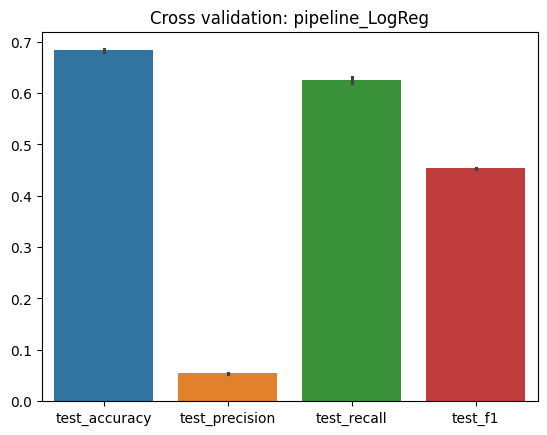

In [42]:
scores_df
g= sns.barplot(data = scores_df)
g.set_title("Cross validation: pipeline_LogReg")

# 2 cross validate on the model: pipeline_Random_Forest

In [43]:
from sklearn.model_selection import cross_validate
scores = cross_validate(pipeline_Random_Forest, X_train, y_train, cv = my_cv, scoring = my_metrics)
scores_df = pd.DataFrame(scores)
print("cross_validate: pipeline_Random_Forest")
scores_df

cross_validate: pipeline_Random_Forest


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,74.234232,0.443801,0.971301,0.559829,0.657296,0.697334
1,72.587640,0.445196,0.970691,0.540426,0.652560,0.690928
2,72.153248,0.463132,0.970463,0.534188,0.650052,0.688050
3,71.161124,0.464202,0.970008,0.523404,0.647090,0.684203
4,70.656308,0.448866,0.970387,0.530303,0.667556,0.701359


In [44]:
scores.describe()

AttributeError: 'dict' object has no attribute 'describe'

In [ ]:
for k,v in scores.items():
    print(f"Mean {k}: {v.mean():.3f}")
    print(f"(stdev = {v.std():.3f}")

In [ ]:
scores_df = scores_df.drop(['fit_time','score_time'], axis =1)

In [ ]:
scores_df

In [ ]:
g = sns.barplot(data = scores_df)
g.set_title("Cross validation: pipeline_Random_Forest")

## 3. Random Forest Regressor

In [ ]:
RandomForestRegressor()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

pipeline_Random_Forest_Regressor = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', RandomForestRegressor()) ])
pipeline_Random_Forest_Regressor

## HyperParemeter tuning

### GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#LogisticRegression()

In [ ]:
#model = pipeline_LogReg
model = pipeline_Random_Forest
hyperparams = {'classifier__C': [1, 2, 3]}
gridsearch = GridSearchCV(model, hyperparams, cv =5, scoring = 'recall')  # use different metrics
gridsearch

In [ ]:
gridsearch.fit(X_train, y_train)

In [ ]:
y_train_pred = gridsearch.predict(X_train)

print(classification_report(y_train, y_train_pred, target_names=target_names))